# ML questions Ultralow Vaccine Distribution Data



## What this dataset can answer

| Original question | What this notebook does |
|---|---|
| Recovery time from excursion severity | Uses temperature change as a simple proxy. Full recovery analysis needs real excursion and recovery labels. |
| Factors associated with temperature rise | Yes: uses time, mean temperature, sensor spread, O2, and CO2. |
| Can sensors validate one another? | Yes: uses one temperature channel to estimate another. |
| Normal vs investigation-needed? | Yes, using unusually rapid temperature change as a learning label. |
| Probability of a warm excursion | Yes, using the warmest 10% of observed windows as a relative label. |
| Possible freezing exposure | Not meaningful here without a product-specific threshold. |
| Open-door or handling event | Only a possible-event proxy; the dataset has no confirmed door-event labels. |

In [15]:
# These are the only libraries used in this notebook.
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans

drive.mount('/content/drive')
plt.style.use('seaborn-v0_8-whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the data

This finds the existing ZIP file in Drive, extracts it, and loads the first temperature test. The code does not depend on a particular sensor brand.

In [16]:
# Find the dataset ZIP in Google Drive.
drive_root = Path('/content/drive/MyDrive')
zip_files = list(drive_root.rglob('14888121*.zip'))
if not zip_files:
    raise FileNotFoundError('Could not find the dataset ZIP in Google Drive.')

extract_dir = Path('/content/ultralow_data')
extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_files[0]) as z:
    z.extractall(extract_dir)

data_dir = next(extract_dir.rglob('14888121'))
raw = pd.read_csv(data_dir / 'Test1_TempCO2O2.csv', low_memory=False).iloc[2:].copy()
raw['hours'] = pd.to_timedelta(raw['Time Elapsed'].astype(str), errors='coerce').dt.total_seconds() / 3600

# Convert all possible measurement columns to numbers.
for column in raw.columns:
    if column not in ['date', 'time', 'Time Elapsed', 'hours']:
        raw[column] = pd.to_numeric(raw[column], errors='coerce')
raw = raw.dropna(subset=['hours'])
print('Rows loaded:', len(raw))

Rows loaded: 112267


In [17]:
# Find usable temperature columns. O2 and CO2 are kept as environmental features, not temperatures.
not_temperature = {'hours', 'O2', 'CO2', 'Ambient', 'Unnamed: 63', 'Unnamed: 64'}
temp_columns = [c for c in raw.columns if c not in not_temperature and pd.api.types.is_numeric_dtype(raw[c]) and raw[c].notna().sum() > 100]
print('Temperature channels found:', len(temp_columns))
print('First five channels:', temp_columns[:5])

# Make one simple table with the averages we will use.
data = raw[['hours', 'O2', 'CO2'] + temp_columns].copy()
data['mean_temperature'] = data[temp_columns].mean(axis=1)
data['sensor_spread'] = data[temp_columns].max(axis=1) - data[temp_columns].min(axis=1)
data = data.dropna(subset=['mean_temperature', 'sensor_spread', 'O2', 'CO2']).reset_index(drop=True)
data[['hours', 'mean_temperature', 'sensor_spread', 'O2', 'CO2']].head()

Temperature channels found: 57
First five channels: ['Pod20', 'Pod19', 'Pod18', 'Pod17', 'Pod16']


,hours,mean_temperature,sensor_spread,O2,CO2
0,0.000000,-19.891126,155.5722,21.658532,0.350565
1,0.005000,-20.093453,155.9646,21.656856,0.351209
2,0.008056,-20.272979,154.9404,21.656094,0.350967
3,0.010833,-20.359884,155.1420,21.655332,0.351369
4,0.013611,-20.464316,154.4886,21.654570,0.351369


## 2. Basic visualization

The line is the average across all temperature channels. The shaded area shows how far apart the channels are. A wider area means more disagreement between sensors.

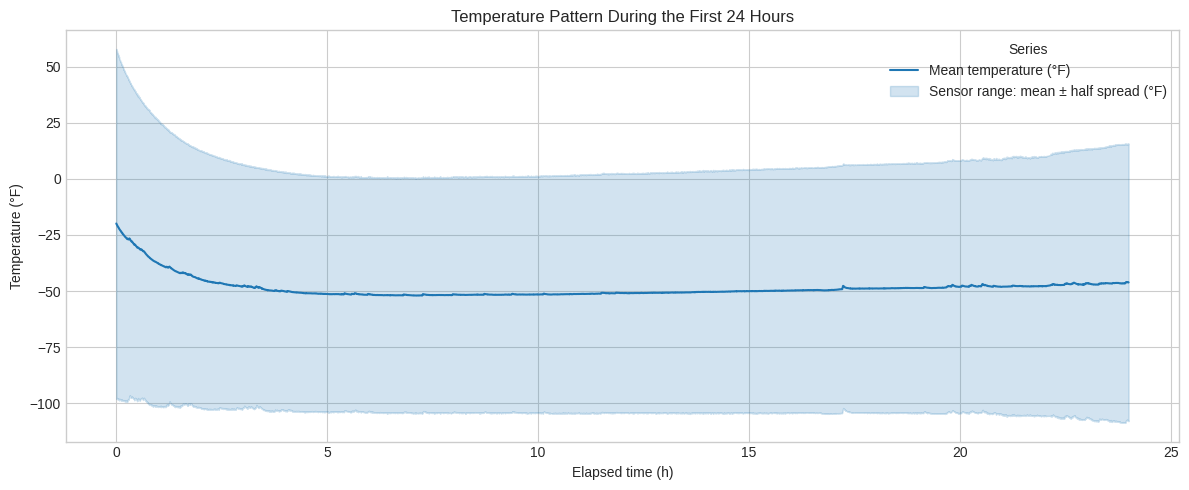

In [18]:
# Show only the first 24 hours so the plot is easy to read.
first_day = data[data['hours'] <= 24]
plt.figure(figsize=(12, 5))
plt.plot(first_day['hours'], first_day['mean_temperature'], color='tab:blue', label='Mean temperature (°F)')

# Calculate range for fill_between
lower_bound = first_day['mean_temperature'] - first_day['sensor_spread']/2
upper_bound = first_day['mean_temperature'] + first_day['sensor_spread']/2

plt.fill_between(first_day['hours'], lower_bound, upper_bound, color='tab:blue', alpha=.2, label='Sensor range: mean ± half spread (°F)')

plt.title('Temperature Pattern During the First 24 Hours')
plt.xlabel('Elapsed time (h)')
plt.ylabel('Temperature (°F)')
plt.legend(title='Series')
plt.tight_layout()
plt.show()

## 3. Linear regression: can one sensor estimate another?

**Question:** Can the existing temperature sensors help validate one another?

We use the first sensor to predict the second sensor. If the points are close to the dashed line, the two channels have a consistent relationship. Large gaps may be worth reviewing for placement or sensor disagreement.

R-squared: 0.775


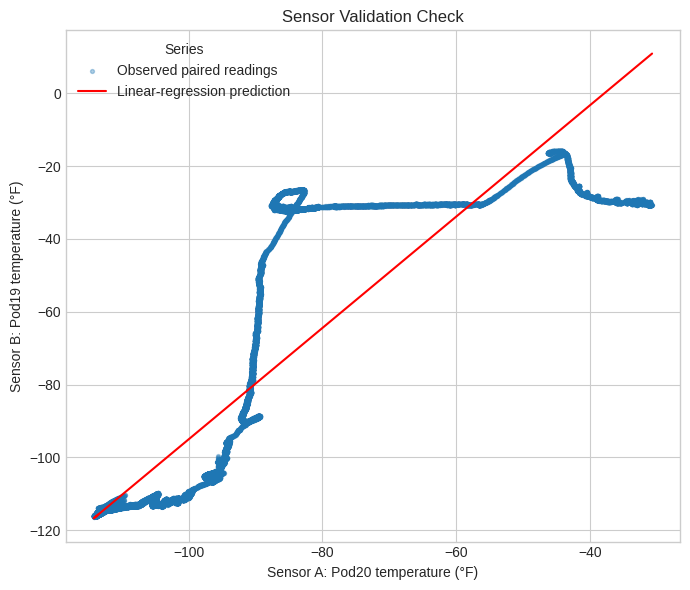

In [19]:
sensor_a, sensor_b = temp_columns[0], temp_columns[1]
sensor_data = data[[sensor_a, sensor_b]].dropna()
model_sensor = LinearRegression().fit(sensor_data[[sensor_a]], sensor_data[sensor_b])
predicted_b = model_sensor.predict(sensor_data[[sensor_a]])
r2 = model_sensor.score(sensor_data[[sensor_a]], sensor_data[sensor_b])
print(f'R-squared: {r2:.3f}')

plt.figure(figsize=(7, 6))
plt.scatter(sensor_data[sensor_a], sensor_data[sensor_b], s=8, alpha=.35, label='Observed paired readings')
plt.plot(sensor_data[sensor_a], predicted_b, color='red', label='Linear-regression prediction')
plt.title('Sensor Validation Check')
plt.xlabel(f'Sensor A: {sensor_a} temperature (°F)')
plt.ylabel(f'Sensor B: {sensor_b} temperature (°F)')
plt.legend(title='Series')
plt.tight_layout()
plt.show()

## 4. Linear regression: what is associated with temperature change?

**Question:** Which available factors are associated with temperature change?

The target is the change in average temperature at the next reading. The bar chart compares the direction of each relationship: positive bars are associated with warming, while negative bars are associated with cooling. This shows association, not cause.

R-squared: 0.003


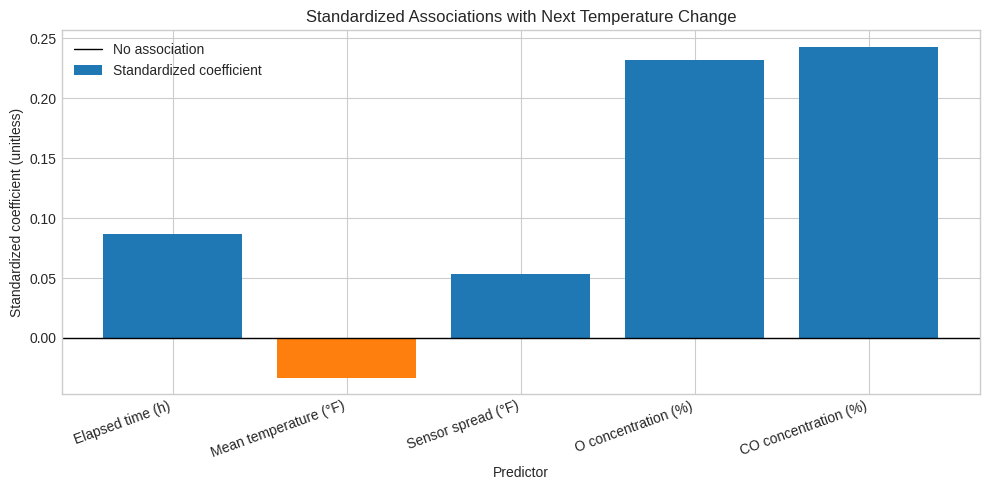

In [20]:
# The shift(-1) makes the target the NEXT reading, not the current one.
data['next_temperature'] = data['mean_temperature'].shift(-1)
data['next_change'] = data['next_temperature'] - data['mean_temperature']
model_data = data.dropna(subset=['next_change']).copy()
features = ['hours', 'mean_temperature', 'sensor_spread', 'O2', 'CO2']
feature_labels = ['Elapsed time (h)', 'Mean temperature (°F)', 'Sensor spread (°F)', 'O concentration (%)', 'CO concentration (%)']
X = model_data[features]
y = model_data['next_change']
change_model = LinearRegression().fit(X, y)
print(f'R-squared: {change_model.score(X, y):.3f}')

# Standardize all variables before plotting, so every coefficient is unitless and comparable.
X_standardized = (X - X.mean()) / X.std()
y_standardized = (y - y.mean()) / y.std()
standardized_model = LinearRegression().fit(X_standardized, y_standardized)
coefs = standardized_model.coef_

plt.figure(figsize=(10, 5))
plt.bar(feature_labels, coefs, color=['tab:blue' if value >= 0 else 'tab:orange' for value in coefs], label='Standardized coefficient')
plt.axhline(0, color='black', linewidth=1, label='No association')
plt.title('Standardized Associations with Next Temperature Change')
plt.xlabel('Predictor')
plt.ylabel('Standardized coefficient (unitless)')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Logistic regression: normal or investigation-needed?

**Question:** Can the system classify whether the next reading is stable or needs investigation?

Because this dataset has no confirmed failure labels, we make a simple learning label: the 10% largest next-temperature changes are called `investigation-needed`. This does not mean a real failure happened.

Investigation-needed windows: 11228 out of 112266


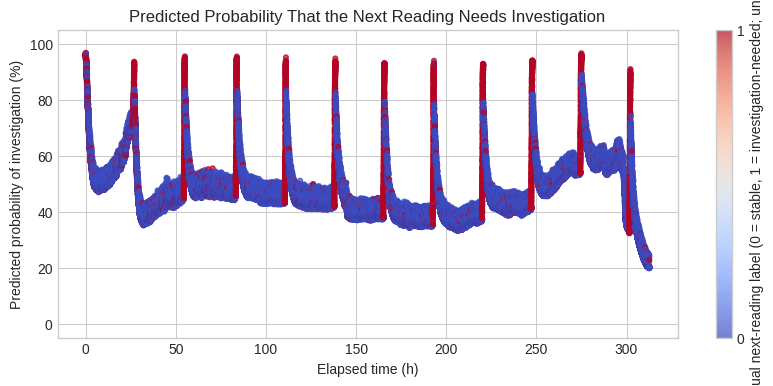

In [21]:
# Create a simple 0/1 label. 1 means the next change is unusually large for THIS dataset.
cutoff = model_data['next_change'].abs().quantile(.90)
model_data['investigation_needed'] = (model_data['next_change'].abs() >= cutoff).astype(int)

X = model_data[features]
y = model_data['investigation_needed']
investigation_model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, y)
probability_percent = 100 * investigation_model.predict_proba(X)[:, 1]
print('Investigation-needed windows:', y.sum(), 'out of', len(y))

plt.figure(figsize=(10, 4))
scatter = plt.scatter(model_data['hours'], probability_percent, c=y, cmap='coolwarm', vmin=0, vmax=1, s=12, alpha=.7)
colorbar = plt.colorbar(scatter, ticks=[0, 1])
colorbar.set_label('Actual next-reading label (0 = stable, 1 = investigation-needed; unitless)')
plt.title('Predicted Probability That the Next Reading Needs Investigation')
plt.xlabel('Elapsed time (h)')
plt.ylabel('Predicted probability of investigation (%)')
plt.ylim(-5, 105)
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Safely ensure the variables exist by checking the global namespace
if 'data' in globals() and 'features' in globals():
    if 'model_data' not in globals() or 'investigation_model' not in globals():
        # Reconstruct model_data if missing
        data['next_temperature'] = data['mean_temperature'].shift(-1)
        data['next_change'] = data['next_temperature'] - data['mean_temperature']
        model_data = data.dropna(subset=['next_change']).copy()
        cutoff = model_data['next_change'].abs().quantile(.90)
        model_data['investigation_needed'] = (model_data['next_change'].abs() >= cutoff).astype(int)

        # Re-fit the model
        X = model_data[features]
        y = model_data['investigation_needed']
        investigation_model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, y)

    # Use the verified data and model for evaluation
    X_eval = model_data[features]
    y_true = model_data['investigation_needed']
    y_pred = investigation_model.predict(X_eval)

    # Calculate and display metrics
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Overall Model Accuracy: {accuracy:.2%}\n")
    print("Confusion Matrix:")
    print(pd.DataFrame(conf_matrix,
                       index=['Actual: Stable', 'Actual: Investigation'],
                       columns=['Predicted: Stable', 'Predicted: Investigation']))

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred))
else:
    print("Error: Base data is missing. Please run the data loading and preparation cells at the top of the notebook first.")

Overall Model Accuracy: 71.27%

Confusion Matrix:
                       Predicted: Stable  Predicted: Investigation
Actual: Stable                     74827                     26211
Actual: Investigation               6043                      5185

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82    101038
           1       0.17      0.46      0.24     11228

    accuracy                           0.71    112266
   macro avg       0.55      0.60      0.53    112266
weighted avg       0.85      0.71      0.76    112266



## 6. Logistic regression: probability of a warm relative reading

**Question:** What is the probability that the next reading is relatively warm?

Here, `warm` means the next reading is in the warmest 10% of this dataset. It is not a manufacturer temperature limit.

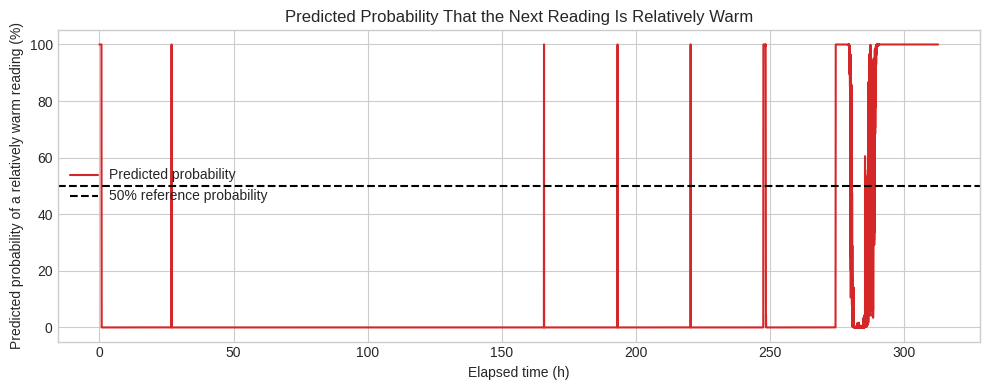

In [23]:
# Make a second 0/1 learning label based on the next temperature value.
warm_cutoff = model_data['next_temperature'].quantile(.90)
model_data['warm_relative'] = (model_data['next_temperature'] >= warm_cutoff).astype(int)
warm_model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(model_data[features], model_data['warm_relative'])
warm_probability_percent = 100 * warm_model.predict_proba(model_data[features])[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(model_data['hours'], warm_probability_percent, color='tab:red', label='Predicted probability')
plt.axhline(50, color='black', linestyle='--', label='50% reference probability')
plt.title('Predicted Probability That the Next Reading Is Relatively Warm')
plt.xlabel('Elapsed time (h)')
plt.ylabel('Predicted probability of a relatively warm reading (%)')
plt.ylim(-5, 105)
plt.legend()
plt.tight_layout()
plt.show()

# Number of Datapoints that are being used

In [24]:
total_datapoints = model_data.shape[0]
df_total_datapoints = pd.DataFrame({'Description': ['Total Datapoints for Models'], 'Count': [total_datapoints]})
display(df_total_datapoints)

,Description,Count
0,Total Datapoints for Models,112266


## 7. K-means: find groups of similar temperature behavior

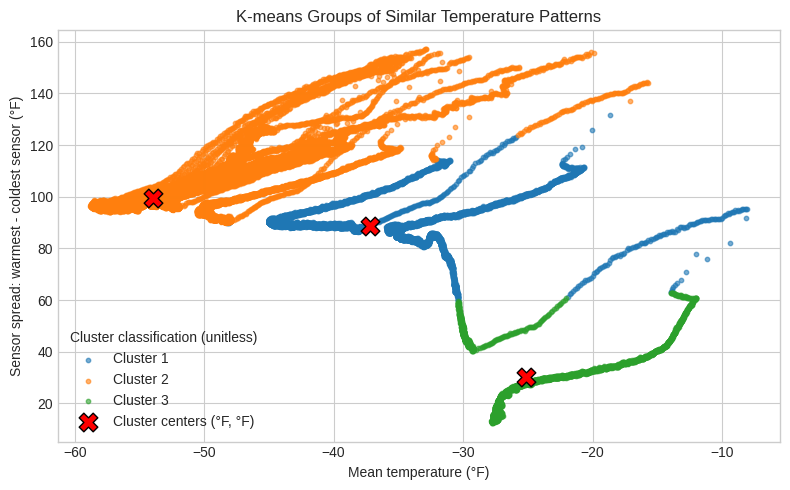

Cluster centers (mean temperature °F, sensor spread °F):
   mean_temperature (°F)  sensor_spread (°F)
0             -37.185013           88.529918
1             -53.916630           99.626365
2             -25.130801           30.313220


In [25]:
# K-means groups each row into one of three temperature-pattern clusters.
cluster_features = data[['mean_temperature', 'sensor_spread']].dropna().copy()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_features)

plt.figure(figsize=(8, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for cluster_id, color in enumerate(colors):
    mask = clusters == cluster_id
    plt.scatter(cluster_features.loc[mask, 'mean_temperature'],
                cluster_features.loc[mask, 'sensor_spread'],
                c=color, s=10, alpha=.6, label=f'Cluster {cluster_id + 1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=180, edgecolor='black', label='Cluster centers (°F, °F)')

plt.title('K-means Groups of Similar Temperature Patterns')
plt.xlabel('Mean temperature (°F)')
plt.ylabel('Sensor spread: warmest - coldest sensor (°F)')
plt.legend(title='Cluster classification (unitless)')
plt.tight_layout()
plt.show()

print('Cluster centers (mean temperature °F, sensor spread °F):')
print(pd.DataFrame(kmeans.cluster_centers_, columns=['mean_temperature (°F)', 'sensor_spread (°F)']))

In [26]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform the features used for clustering
cluster_features_scaled = scaler.fit_transform(cluster_features)

# 3. Create a DataFrame for the scaled data to maintain readability
cluster_features_scaled_df = pd.DataFrame(cluster_features_scaled, columns=['mean_temperature_scaled', 'sensor_spread_scaled'])

print("Features have been scaled. Mean is now approximately 0 and Standard Deviation is 1.")
display(cluster_features_scaled_df.describe().round(2))

Features have been scaled. Mean is now approximately 0 and Standard Deviation is 1.


,mean_temperature_scaled,sensor_spread_scaled
count,112267.00,112267.00
mean,0.00,0.00
std,1.00,1.00
min,-0.93,-5.02
25%,-0.76,0.01
50%,-0.40,0.09
75%,0.47,0.15
max,4.41,3.80


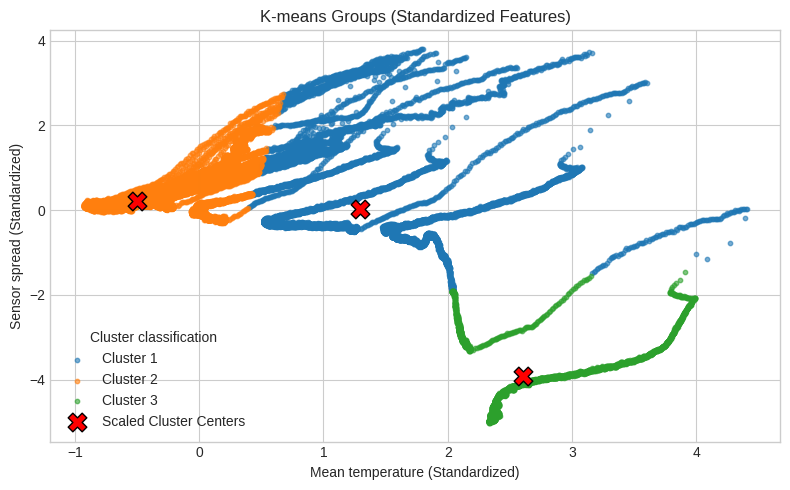

New Cluster centers in actual units (°F):
   mean_temperature (°F)  sensor_spread (°F)
0             -37.625777           95.242318
1             -54.662919           98.411381
2             -25.149478           30.829044


In [27]:
# Re-running K-means on the scaled data
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_scaled = kmeans_scaled.fit_predict(cluster_features_scaled_df)

plt.figure(figsize=(8, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for cluster_id, color in enumerate(colors):
    mask = clusters_scaled == cluster_id
    plt.scatter(cluster_features_scaled_df.loc[mask, 'mean_temperature_scaled'],
                cluster_features_scaled_df.loc[mask, 'sensor_spread_scaled'],
                c=color, s=10, alpha=.6, label=f'Cluster {cluster_id + 1}')

# Plotting the centers in the scaled coordinate system
plt.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1],
            c='red', marker='X', s=180, edgecolor='black', label='Scaled Cluster Centers')

plt.title('K-means Groups (Standardized Features)')
plt.xlabel('Mean temperature (Standardized)')
plt.ylabel('Sensor spread (Standardized)')
plt.legend(title='Cluster classification')
plt.tight_layout()
plt.show()

# To see the actual physical values of these new centers, we inverse the scaling
actual_centers = scaler.inverse_transform(kmeans_scaled.cluster_centers_)
print('New Cluster centers in actual units (°F):')
print(pd.DataFrame(actual_centers, columns=['mean_temperature (°F)', 'sensor_spread (°F)']))

## Final takeaway

- Linear regression answers: how much? For example, how much one sensor changes with another.
- Logistic regression answers: how likely? For example, what is the probability of an unusual next reading.
- K-means answers: which readings look similar? It groups patterns without needing known labels.

For a real lab project, add verified temperature limits and confirmed event labels before using these models for operational decisions.